# 224 — Finding a domain and drawing its edges are different problems, and the truth set runs out first

**Question:** notebooks [220](./220_mhc_region_map_and_coverage.ipynb) to
[223](./223_mhc_platform_vs_ig_domain.ipynb) all report one number per arm per species: how
many MHC domains it recovered, where "recovered" means the transferred family matched and the
interval reached IoU ≥ 0.5. That number fuses two things a reader will assume are one. Did the
search reach the protein at all, and did it draw the right box around the domain? This notebook
separates them, then asks how far out either question still has an answer.

Three claims are tested here and one of them is a limitation rather than a result.

1. Where a tool can score a true positive on an MHC molecule is decided by the Pfam
   annotation, not by divergence. The tool cliff and the annotation cliff are the same line, so
   the benchmark cannot tell "the molecules stopped being findable" apart from "Pfam stopped
   annotating them". TAP1 and TAP2 are the control, and fly — further out than ciona and yet
   far better scored, on the strength of one annotated protein — is the proof.
2. Called and delimited come apart, and they come apart in opposite directions for different
   tools. Reporting only the favourable half of that split would be dishonest in either
   direction.
3. Among kmerseek's own alphabets the HP ordering holds on a metric where kmerseek loses
   overall, which is the point: the ordering is not an artifact of a self-flattering metric.

Every denominator here is computed from the run's own `truth/*_domain_map.parquet` files. The
pipeline's `recall_reachable` and `n_reachable_instances` columns in `all_domain_metrics.parquet`
are never read, in this notebook or in 223.

Siblings: [220](./220_mhc_region_map_and_coverage.ipynb) maps the region,
[221](./221_mhc_cross_species_detection_depth.ipynb) walks it out to 2,000 Mya,
[222](./222_mhc_synteny_target_side.ipynb) asks what the hits landed on, and
[223](./223_mhc_platform_vs_ig_domain.ipynb) explains why the IoU cut behaves the way it does.

MHC-window genes: 221
curated MHC molecules + peptide-loading control: 24
true (gene, family) pairs on those: 51
focus arms in the raw call table: 16
species: ['mouse', 'chicken', 'zebrafish', 'ciona', 'fly', 'worm', 'yeast', 'arabidopsis', 'ecoli']

shape: (6, 3)
┌───────────────────┬─────────┬───────────┐
│ mhc_class         ┆ n_genes ┆ n_domains │
│ ---               ┆ ---     ┆ ---       │
│ str               ┆ u32     ┆ u32       │
╞═══════════════════╪═════════╪═══════════╡
│ II beta           ┆ 7       ┆ 14        │
│ II alpha          ┆ 6       ┆ 12        │
│ I classical       ┆ 3       ┆ 9         │
│ I non-classical   ┆ 3       ┆ 7         │
│ processing (ctrl) ┆ 3       ┆ 5         │
│ I related (MIC)   ┆ 2       ┆ 4         │
└───────────────────┴─────────┴───────────┘


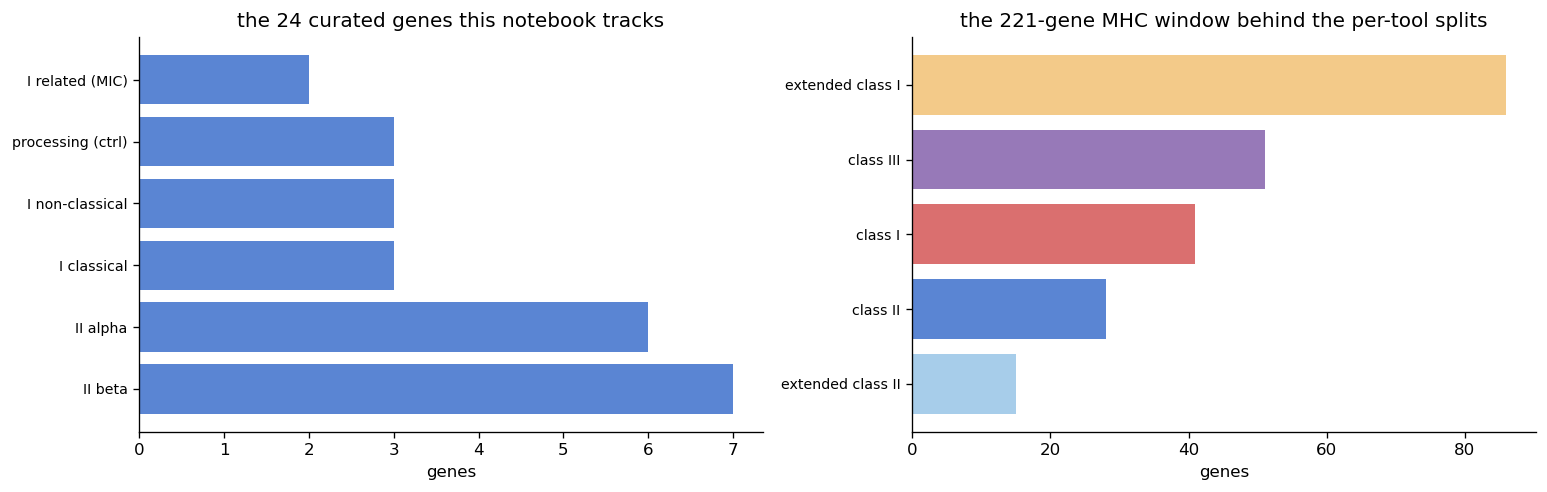

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

import mhc_region_utils as mu
import ortholog_analysis_utils as ou

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

gene_map = mu.load_chr6_gene_map()
window = mu.load_mhc_window(gene_map)
CORE = mu.core_truth()
CORE_ACC = CORE["query_acc"].unique().to_list()
WIN_ACC = window["accession"].to_list()

ARMS = mu.focus_arms()
BASELINE_TOOLS = [t for t in ARMS["tool"].unique().to_list() if t != "kmerseek"]
HP_ARMS = ["hp_pbotc_1st_ed2_k19_lcTrue", "hp_pbotc_1st_ed2_k21_lcTrue",
           "hp_pbotc_1st_ed2_k24_lcTrue", "hp_thomas_dill2_k26_lcTrue"]
KM_ARMS = HP_ARMS + ["dayhoff6_k12_lcTrue", "funcgroups8_k12_lcTrue", "protein20_k10_lcTrue"]
SP = mu.SPECIES_ORDER

print(f"MHC-window genes: {window.height}")
print(f"curated MHC molecules + peptide-loading control: {len(CORE_ACC)}")
print(f"true (gene, family) pairs on those: {CORE.height}")
print(f"focus arms in the raw call table: {ARMS.height}")
print(f"species: {SP}")
print()
comp = (CORE.group_by("mhc_class").agg(n_genes=pl.col("query_acc").n_unique(),
                                       n_domains=pl.len())
            .sort("n_domains", descending=True))
with pl.Config(tbl_rows=20, tbl_width_chars=140):
    print(comp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].barh(range(comp.height), comp["n_genes"], color="#4878CF", alpha=0.9)
axes[0].set_yticks(range(comp.height))
axes[0].set_yticklabels(comp["mhc_class"], fontsize=8.5)
axes[0].set_xlabel("genes")
axes[0].set_title("the 24 curated genes this notebook tracks")
sub = window.group_by("mhc_subregion").len().sort("len")
axes[1].barh(range(sub.height), sub["len"],
             color=[mu.MHC_SUBREGION_COLORS[s] for s in sub["mhc_subregion"]], alpha=0.9)
axes[1].set_yticks(range(sub.height))
axes[1].set_yticklabels(sub["mhc_subregion"], fontsize=8.5)
axes[1].set_xlabel("genes")
axes[1].set_title(f"the {window.height}-gene MHC window behind the per-tool splits")
for ax in axes:
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "224_scope.png", dpi=200)

## 1. The tool cliff and the annotation cliff are the same line

Each cell below is one MHC molecule against one target proteome, in three states: the arms made
no call on that gene, they made calls but delimited none of its domains, or they delimited at
least one. Two panels: the nine baseline tools pooled, and the four HP kmerseek arms pooled.

Behind each cell is the thing the state has to be read against — whether any of that gene's
Pfam families is annotated on any protein in that target proteome. A cell with no reachable
family cannot produce a true positive for any tool at any sensitivity, because there is no
instance in the answer key to match.

TAP1 and TAP2 are in the figure as the control. They sit inside the class II region but are ABC
transporters, a fold shared with bacteria, and their two Pfam families are annotated in all nine
proteomes. If detection simply died with distance they would die too.

Pfam instances in each target proteome, per MHC family (the recall denominator):
shape: (7, 11)
┌─────────┬───────┬─────────┬───────────┬───┬───────┬─────────────┬───────┬──────────────────────┐
│ pfam_id ┆ mouse ┆ chicken ┆ zebrafish ┆ … ┆ yeast ┆ arabidopsis ┆ ecoli ┆ pfam                 │
│ ---     ┆ ---   ┆ ---     ┆ ---       ┆   ┆ ---   ┆ ---         ┆ ---   ┆ ---                  │
│ str     ┆ i64   ┆ i64     ┆ i64       ┆   ┆ i64   ┆ i64         ┆ i64   ┆ str                  │
╞═════════╪═══════╪═════════╪═══════════╪═══╪═══════╪═════════════╪═══════╪══════════════════════╡
│ PF07654 ┆ 95    ┆ 11      ┆ 30        ┆ … ┆ 0     ┆ 0           ┆ 0     ┆ PF07654 C1-set       │
│ PF00005 ┆ 53    ┆ 9       ┆ 29        ┆ … ┆ 31    ┆ 120         ┆ 78    ┆ PF00005 ABC_tran     │
│ PF00664 ┆ 23    ┆ 4       ┆ 16        ┆ … ┆ 10    ┆ 44          ┆ 5     ┆ PF00664 ABC_membrane │
│ PF00129 ┆ 37    ┆ 2       ┆ 6         ┆ … ┆ 0     ┆ 0           ┆ 0     ┆ PF00129 MHC_I        │
│ PF00993 ┆ 5

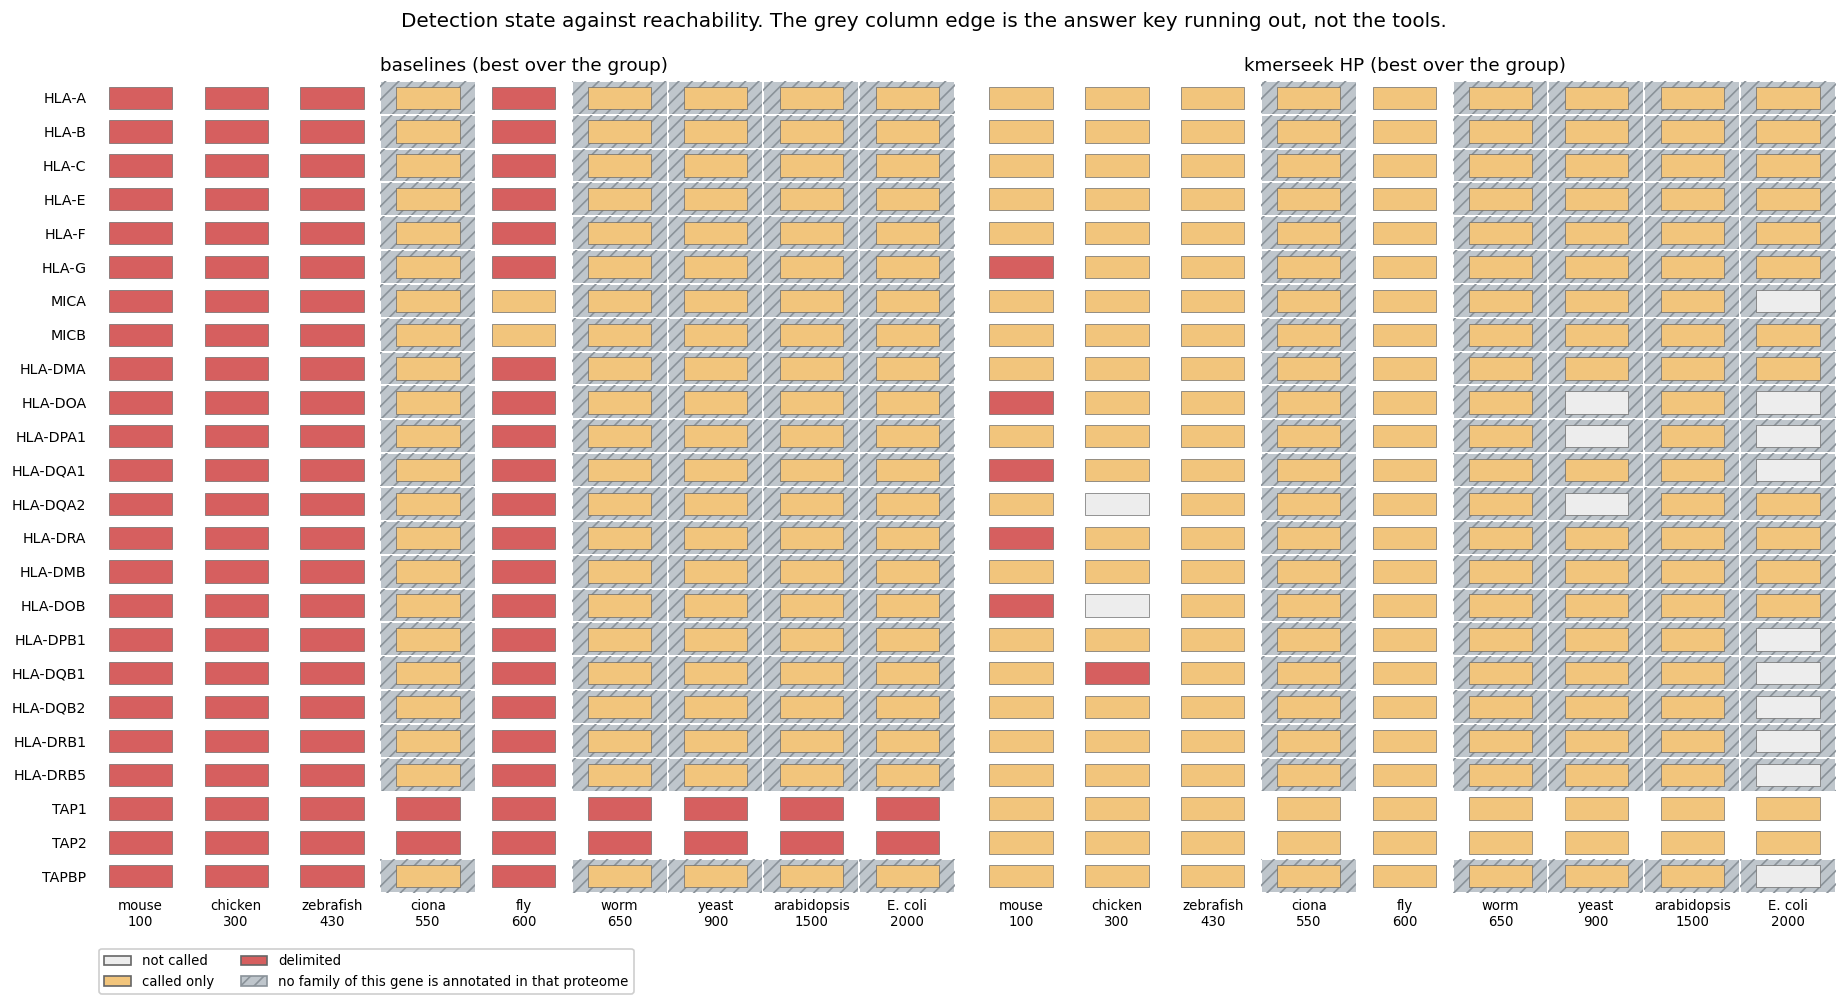

In [2]:
# Zero-filled grid. A (gene, family, arm, species) cell with no call has no row in the call
# table, and dropping it would shrink the denominator to the cells that already succeeded.
G = mu.domain_grid(CORE, SP)
G = G.with_columns(group=pl.when(pl.col("tool") == "kmerseek").then(pl.lit("kmerseek HP"))
                          .otherwise(pl.lit("baselines")))
G = G.filter((pl.col("group") == "baselines") | pl.col("variant").is_in(HP_ARMS))

# Did the arm group call anything at all on that gene, regardless of family? That is a
# different question from "did it call the right family", so it is counted separately.
any_call = (mu.focus_calls()
              .filter(pl.col("query_acc").is_in(CORE_ACC))
              .with_columns(group=pl.when(pl.col("tool") == "kmerseek")
                                    .then(pl.lit("kmerseek HP")).otherwise(pl.lit("baselines")))
              .filter((pl.col("group") == "baselines") | pl.col("variant").is_in(HP_ARMS))
              .group_by("group", "species", "query_acc").agg(n_any=pl.len())
              .collect())

gene_state = (G.group_by("group", "species", "query_acc", "hgnc_symbol", "mhc_class")
               .agg(n_delimited=(pl.col("best_iou") >= 0.5).sum(), n_domains=pl.len())
               .join(any_call, on=["group", "species", "query_acc"], how="left")
               .with_columns(n_any=pl.col("n_any").fill_null(0))
               .with_columns(state=pl.when(pl.col("n_delimited") > 0).then(pl.lit("delimited"))
                                    .when(pl.col("n_any") > 0).then(pl.lit("called only"))
                                    .otherwise(pl.lit("not called"))))

# Reachability: is any of the gene's true families annotated in that target proteome?
fams = CORE["pfam_id"].unique().to_list()
reach_fam = mu.target_family_counts(fams, SP)
reach_gene = (CORE.select("query_acc", "hgnc_symbol", "pfam_id")
                  .join(reach_fam, on="pfam_id", how="inner")
                  .group_by("query_acc", "hgnc_symbol", "species")
                  .agg(n_reachable_families=(pl.col("n_target_proteins") > 0).sum(),
                       n_families=pl.len()))

print("Pfam instances in each target proteome, per MHC family (the recall denominator):")
with pl.Config(tbl_rows=20, tbl_width_chars=200):
    print(reach_fam.pivot(on="species", index="pfam_id", values="n_target_proteins")
                   .select(["pfam_id"] + SP)
                   .with_columns(pfam=pl.col("pfam_id").replace_strict(
                       mu.pfam_label(fams), default=pl.col("pfam_id"))))

past = (G.filter((pl.col("group") == "baselines") & (pl.col("best_iou") >= 0.5)
                 & pl.col("species").is_in(mu.PRE_MHC_SPECIES))
          .group_by("species", "pfam_id")
          .agg(genes_delimited=pl.col("query_acc").n_unique(),
               tools=pl.col("tool").n_unique())
          .sort("species", "pfam_id"))
print("\nPast zebrafish, which family still carries a delimited MHC-gene domain:")
with pl.Config(tbl_rows=20, tbl_width_chars=160):
    print(past)

summary = (gene_state.join(reach_gene, on=["query_acc", "hgnc_symbol", "species"], how="left")
                     .group_by("group", "species")
                     .agg(delimited=(pl.col("state") == "delimited").sum(),
                          called_only=(pl.col("state") == "called only").sum(),
                          not_called=(pl.col("state") == "not called").sum(),
                          genes_with_a_reachable_family=(pl.col("n_reachable_families") > 0).sum())
                     .sort("group", "species"))
print("\nPer species, over the 24 curated genes:")
with pl.Config(tbl_rows=30, tbl_width_chars=180):
    print(summary)

ROWS = (CORE.select("hgnc_symbol", "mhc_class").unique()
            .sort(["mhc_class", "hgnc_symbol"])["hgnc_symbol"].to_list())
STATE_COLOR = {"not called": "#EDEDED", "called only": "#F2C57C", "delimited": "#D65F5F"}

fig, axes = plt.subplots(1, 2, figsize=(15.5, 8.4), sharey=True)
for ax, grp in zip(axes, ["baselines", "kmerseek HP"]):
    for j, sp in enumerate(SP):
        for i, sym in enumerate(ROWS):
            r = gene_state.filter((pl.col("group") == grp) & (pl.col("species") == sp)
                                  & (pl.col("hgnc_symbol") == sym))
            st = r["state"][0] if r.height else "not called"
            rr = reach_gene.filter((pl.col("species") == sp) & (pl.col("hgnc_symbol") == sym))
            reachable = bool(rr["n_reachable_families"][0] > 0) if rr.height else False
            # Background = whether the answer key has anything to score against here.
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                       facecolor="white" if reachable else "#BFC6CC",
                                       edgecolor="white", linewidth=1.2))
            if not reachable:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor="none",
                                           edgecolor="#8A9299", linewidth=0.0, hatch="///"))
            ax.add_patch(plt.Rectangle((j - 0.33, i - 0.33), 0.66, 0.66,
                                       facecolor=STATE_COLOR[st], edgecolor="#666666",
                                       linewidth=0.4))
    ax.set_xlim(-0.5, len(SP) - 0.5)
    ax.set_ylim(len(ROWS) - 0.5, -0.5)
    ax.set_xticks(range(len(SP)))
    ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in SP], fontsize=8)
    ax.set_title(f"{grp} (best over the group)", fontsize=11)
    for s_ in ("right", "top", "left", "bottom"):
        ax.spines[s_].set_visible(False)
    ax.tick_params(length=0)
axes[0].set_yticks(range(len(ROWS)))
axes[0].set_yticklabels(ROWS, fontsize=8.5)
handles = [mpatches.Patch(facecolor=v, edgecolor="#666666", label=k)
           for k, v in STATE_COLOR.items()]
handles.append(mpatches.Patch(facecolor="#BFC6CC", hatch="///", edgecolor="#8A9299",
                              label="no family of this gene is annotated in that proteome"))
axes[0].legend(handles=handles, fontsize=8, loc="upper left", bbox_to_anchor=(0, -0.06),
               ncol=2, framealpha=0.95)
fig.suptitle("Detection state against reachability. The grey column edge is the answer key "
             "running out, not the tools.", y=0.99)
fig.tight_layout()
fig.savefig(FIG_DIR / "224_detection_reachability_matrix.png", dpi=200)

The two cliffs coincide, and fly proves the causal direction.

The baselines delimit all 24 genes in mouse, chicken and zebrafish. In ciona, worm, yeast,
arabidopsis and E. coli they delimit exactly 2 — TAP1 and TAP2 — and every MHC molecule sits in
the "called only" state. The searches do not stop: calls are still made on every gene at 2,000
Mya. What stops is the answer key. PF00129, PF00993 and PF00969 have zero annotated instances in
all six of those proteomes, and PF07654 has zero in five of them.

Fly is the exception and it is the most informative cell in the figure. At 600 Mya, further out
than ciona at 550, the baselines delimit 22 of the 24 genes. The reason is a single fly protein.
Q9W257 (`BcDNA:RH44966`, 229 residues) is the only entry in the whole fly proteome annotated
with PF07654, and it carries no other Pfam family. That one protein turns 0 delimited MHC
molecules into 20, in five of the nine tools. Remove it and fly looks like ciona.

Detection here is not a function of divergence time. It is a function of whether the answer key
contains one suitable protein, and notebook [223](./223_mhc_platform_vs_ig_domain.ipynb) §5–§6
says which kind: one whose aligned extent stops near the domain's end. Q9W257 is the
single-domain case, in a proteome that has exactly one of them.

So the benchmark cannot separate "MHC molecules stopped being findable" from "Pfam stopped
annotating MHC molecules". Any MHC recall number quoted past zebrafish is measuring the second
while sounding like the first, and the fly column shows the measurement moving with the
annotation rather than with the biology.

TAP1 and TAP2 are the control and they behave the other way. Their families PF00664 and PF00005
are annotated in all nine proteomes, and the baselines delimit both genes in all nine, E. coli
included. Distance alone does not end detection at 550 Mya; the missing denominator does.

The ciona column deserves the extra sentence because it is where the two failure modes look
identical. Here the Pfam map is healthy — 20,234 domain instances over 10,658 ciona proteins in
5,542 families, with the TAP control firing inside the same map — and it genuinely contains no
MHC platform and no C1-set. That is a real denominator fact. In the same run's Swiss-Prot truth
set, which this notebook does not use, ciona has almost no reviewed entries at all, and the
resulting curation gap produced a ciona cliff for every tool that looked exactly like this one.
An answer key can manufacture an evolutionary signal that is not there, which is the same
circularity as above with an independent instance.

TAPBP is worth a look for the same reason. It carries only PF07654, so it drops out with the
class II molecules at ciona even though it is a chaperone rather than an antigen receptor.

## 2. Called, and not delimited: the split runs opposite ways

Section 1 pooled tools. This splits every arm separately, over the whole 221-gene MHC window
rather than the 24 curated molecules, into the three states. The joint distribution is what is
reported: not-called, called-but-not-delimited, delimited, summing to 221 for every bar.

The claim being tested is that kmerseek finds the territory and misses the fenceline while the
profile methods do the reverse. Reporting only "kmerseek makes calls on 220 of 221 genes" or
only "kmerseek delimits 110 to phmmer's 204" would each support a different story, so both go in
the same bar.

Every bar sums to the 221 MHC-window genes. Mouse:
shape: (16, 5)
┌───────────────────────────────┬────────────┬─────────────┬───────────┬───────┐
│ arm                           ┆ not called ┆ called only ┆ delimited ┆ total │
│ ---                           ┆ ---        ┆ ---         ┆ ---       ┆ ---   │
│ str                           ┆ u32        ┆ u32         ┆ u32       ┆ u32   │
╞═══════════════════════════════╪════════════╪═════════════╪═══════════╪═══════╡
│ Folddisco                     ┆ 1          ┆ 4           ┆ 216       ┆ 221   │
│ MMseqs2 iterative             ┆ 1          ┆ 15          ┆ 205       ┆ 221   │
│ HHblits                       ┆ 0          ┆ 16          ┆ 205       ┆ 221   │
│ jackhmmer                     ┆ 2          ┆ 15          ┆ 204       ┆ 221   │
│ phmmer                        ┆ 2          ┆ 15          ┆ 204       ┆ 221   │
│ MMseqs2                       ┆ 2          ┆ 23          ┆ 196       ┆ 221   │
│ Foldseek                      ┆ 2        


mouse, from the raw calls: reaching the right family vs drawing the right box.
The last column is the boundary question with family assignment divided out too:
shape: (16, 5)
┌───────────────────────────────┬──────────────┬────────────────────┬─────────────────┬──────────────────────────┐
│ arm                           ┆ genes_called ┆ genes_right_family ┆ genes_delimited ┆ delim_given_right_family │
│ ---                           ┆ ---          ┆ ---                ┆ ---             ┆ ---                      │
│ str                           ┆ u32          ┆ u32                ┆ u32             ┆ f64                      │
╞═══════════════════════════════╪══════════════╪════════════════════╪═════════════════╪══════════════════════════╡
│ Folddisco                     ┆ 220          ┆ 216                ┆ 216             ┆ 1.0                      │
│ MMseqs2 iterative             ┆ 220          ┆ 219                ┆ 205             ┆ 0.936                    │
│ HHblits          

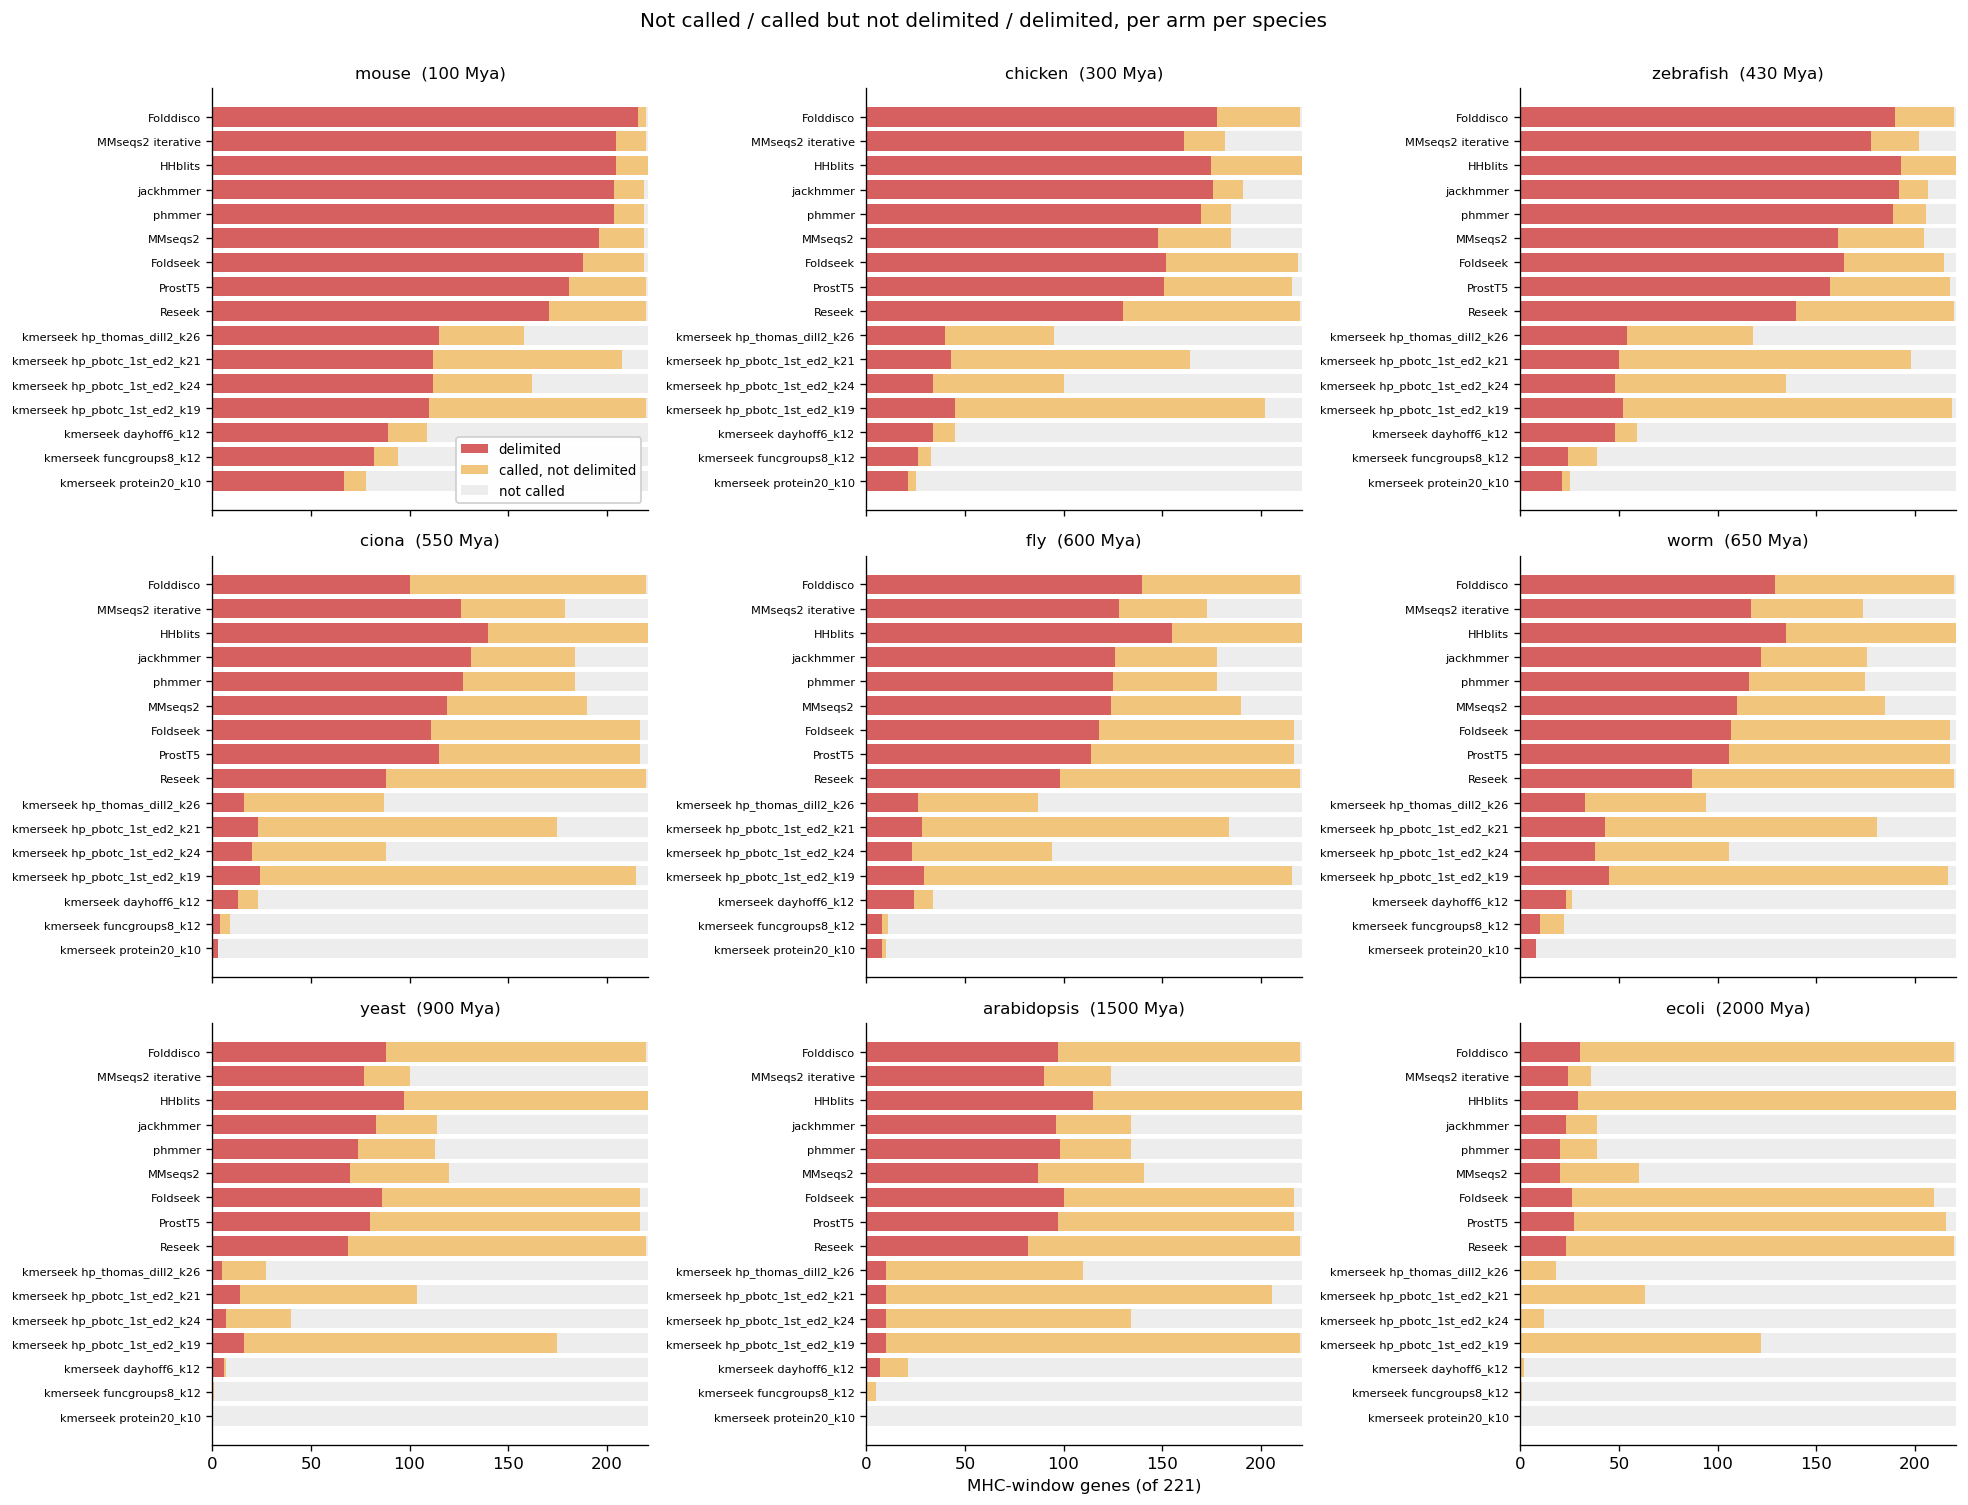

In [3]:
gl = mu.load_gene_level()
grid = (window.select(query_acc="accession")
              .join(ARMS, how="cross")
              .join(pl.DataFrame({"species": SP}), how="cross"))
states = (grid.join(gl.select("query_acc", "tool", "variant", "species", "n_calls", "n_tp"),
                    on=["query_acc", "tool", "variant", "species"], how="left")
              .with_columns(n_calls=pl.col("n_calls").fill_null(0),
                            n_tp=pl.col("n_tp").fill_null(0))
              .with_columns(state=pl.when(pl.col("n_tp") > 0).then(pl.lit("delimited"))
                                    .when(pl.col("n_calls") > 0).then(pl.lit("called only"))
                                    .otherwise(pl.lit("not called")),
                            arm=mu.arm_label(pl.col("tool"), pl.col("variant"))))
tab = (states.group_by("species", "arm", "tool", "state").len()
             .pivot(on="state", index=["species", "arm", "tool"], values="len")
             .fill_null(0))
for c in ["delimited", "called only", "not called"]:
    if c not in tab.columns:
        tab = tab.with_columns(pl.lit(0).alias(c))
tab = tab.with_columns(total=pl.col("delimited") + pl.col("called only") + pl.col("not called"))
print(f"Every bar sums to the {window.height} MHC-window genes. Mouse:")
with pl.Config(tbl_rows=20, tbl_width_chars=180, fmt_str_lengths=42):
    print(tab.filter(pl.col("species") == "mouse")
             .select("arm", "not called", "called only", "delimited", "total")
             .sort("delimited", descending=True))
print("\nDelimited given called, mouse — the fenceline question with the sensitivity")
print("difference divided out:")
cond = (tab.filter(pl.col("species") == "mouse")
           .with_columns(called=pl.col("called only") + pl.col("delimited"))
           .with_columns(delim_given_called=(pl.col("delimited") / pl.col("called")).round(3))
           .select("arm", "called", "delimited", "delim_given_called")
           .sort("delim_given_called", descending=True))
with pl.Config(tbl_rows=20, tbl_width_chars=180, fmt_str_lengths=42):
    print(cond)

# Split the "called but not delimited" mass into two causes: the arm never called a family
# the gene actually has, or it called the right family and missed the boundary.
tpairs = mu.window_truth().select("query_acc", "pfam_id").unique().with_columns(right=pl.lit(True))
raw = (mu.focus_calls()
         .filter((pl.col("species") == "mouse") & pl.col("query_acc").is_in(WIN_ACC))
         .select("query_acc", "pfam_id", "tool", "variant", "is_tp")
         .collect()
         .join(tpairs, on=["query_acc", "pfam_id"], how="left")
         .with_columns(right=pl.col("right").fill_null(False),
                       arm=mu.arm_label(pl.col("tool"), pl.col("variant"))))
cause = (raw.group_by("arm")
            .agg(genes_called=pl.col("query_acc").n_unique(),
                 genes_right_family=pl.col("query_acc").filter(pl.col("right")).n_unique(),
                 genes_delimited=pl.col("query_acc").filter(pl.col("is_tp")).n_unique())
            .with_columns(delim_given_right_family=(pl.col("genes_delimited")
                                                    / pl.col("genes_right_family")).round(3))
            .sort("genes_delimited", descending=True))
print("\nmouse, from the raw calls: reaching the right family vs drawing the right box.")
print("The last column is the boundary question with family assignment divided out too:")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=42):
    print(cause)

ARM_ORDER = (tab.filter(pl.col("species") == "mouse").sort("delimited", descending=True)["arm"]
                .to_list())
fig, axes = plt.subplots(3, 3, figsize=(16.5, 12.5), sharex=True)
for ax, sp in zip(axes.ravel(), SP):
    t = tab.filter(pl.col("species") == sp)
    y = np.arange(len(ARM_ORDER))
    d = np.array([t.filter(pl.col("arm") == a)["delimited"][0] for a in ARM_ORDER], float)
    c = np.array([t.filter(pl.col("arm") == a)["called only"][0] for a in ARM_ORDER], float)
    n = np.array([t.filter(pl.col("arm") == a)["not called"][0] for a in ARM_ORDER], float)
    ax.barh(y, d, color="#D65F5F", label="delimited")
    ax.barh(y, c, left=d, color="#F2C57C", label="called, not delimited")
    ax.barh(y, n, left=d + c, color="#EDEDED", label="not called")
    ax.set_yticks(y)
    ax.set_yticklabels(ARM_ORDER, fontsize=6.8)
    ax.invert_yaxis()
    ax.set_title(f"{sp}  ({mu.SPECIES_MYA[sp]} Mya)", fontsize=10)
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
axes[2, 1].set_xlabel(f"MHC-window genes (of {window.height})")
axes[0, 0].legend(fontsize=8, loc="lower right", framealpha=0.95)
fig.suptitle("Not called / called but not delimited / delimited, per arm per species", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "224_called_vs_delimited.png", dpi=200)

The stated claim is wrong in this run, and the correction matters more than the claim did.

kmerseek is not the arm that finds the territory and misses the fenceline. In mouse,
`hp_pbotc_1st_ed2_k19` makes calls on 220 of 221 window genes — as many as phmmer's 219 — and
delimits 110 against phmmer's 204. Conditioned on having called a gene at all, phmmer delimits
93% of them and kmerseek k19 delimits 50%. So kmerseek does lose on the joint outcome.

But the loss is not in the boundary. Notebook [223](./223_mhc_platform_vs_ig_domain.ipynb) §9
measures the boundary directly, per call, and kmerseek's is the tightest in the run: a median
error of 9 residues against phmmer's 34. The split, counted from the raw calls on the same
genes, is that kmerseek k19 makes a call carrying a family the gene genuinely has on 117 of the
220 genes it touched, and delimits 110 of those 117 — 94.0%, against phmmer's 204 of 218, 93.6%.
The same holds for the other kmerseek arms: 0.95, 0.95 and 0.91 for k21, k24 and thomas_dill
k26. What kmerseek misses is the family, not the fenceline.

So the Pareto statement is real but on a different axis than advertised. kmerseek is
lower-sensitivity in family assignment and tighter in boundary placement. The axis it loses is
the one that carries the headline recall number.

The other pattern in the panels goes the other way. The kmerseek arms hold their "called only"
mass out to E. coli while the baselines' collapses, which is 221's finding restated: whether
those distant calls mean anything is the subject of §5, and this figure makes no claim about
them.

## 3. The whole IoU curve, not a point on it

Section 2 used the run's threshold, IoU ≥ 0.5. Notebook 223 showed that threshold interacts
badly with short domains inside multi-domain proteins, which raises the obvious question of
what happens at other thresholds.

The whole function is shown here, from 0.05 to 0.95, recomputed from the raw `iou` column
rather than from the fixed `is_tp` flag. Showing the function is legitimate; picking a
favourable point on it and quoting that instead of 0.5 would be metric-shopping, and nothing
below does it. The 0.5 line stays marked and every conclusion elsewhere in these notebooks
stays read off it.

The denominator is the 412 distinct (gene, family) truth pairs on the 221 MHC-window genes.
Distinct pairs rather than the 599 instances, because the run's `iou` column is already a
maximum over the instances of a family on a protein, so per-instance recall is not recoverable
from it.

denominator: 412 distinct (gene, family) truth pairs on 221 MHC-window genes



mouse, recall against IoU threshold:
shape: (19, 10)
┌───────────┬────────┬──────────────────────────────┬───────────┬───┬───────────────────────────────┬─────────┬───────────────────┬──────────┐
│ threshold ┆ phmmer ┆ kmerseek hp_thomas_dill2_k26 ┆ Folddisco ┆ … ┆ kmerseek hp_pbotc_1st_ed2_k19 ┆ HHblits ┆ MMseqs2 iterative ┆ Foldseek │
│ ---       ┆ ---    ┆ ---                          ┆ ---       ┆   ┆ ---                           ┆ ---     ┆ ---               ┆ ---      │
│ f64       ┆ f64    ┆ f64                          ┆ f64       ┆   ┆ f64                           ┆ f64     ┆ f64               ┆ f64      │
╞═══════════╪════════╪══════════════════════════════╪═══════════╪═══╪═══════════════════════════════╪═════════╪═══════════════════╪══════════╡
│ 0.05      ┆ 0.978  ┆ 0.488                        ┆ 0.898     ┆ … ┆ 0.456                         ┆ 0.978   ┆ 0.973             ┆ 0.956    │
│ 0.1       ┆ 0.959  ┆ 0.481                        ┆ 0.706     ┆ … ┆ 0.454             

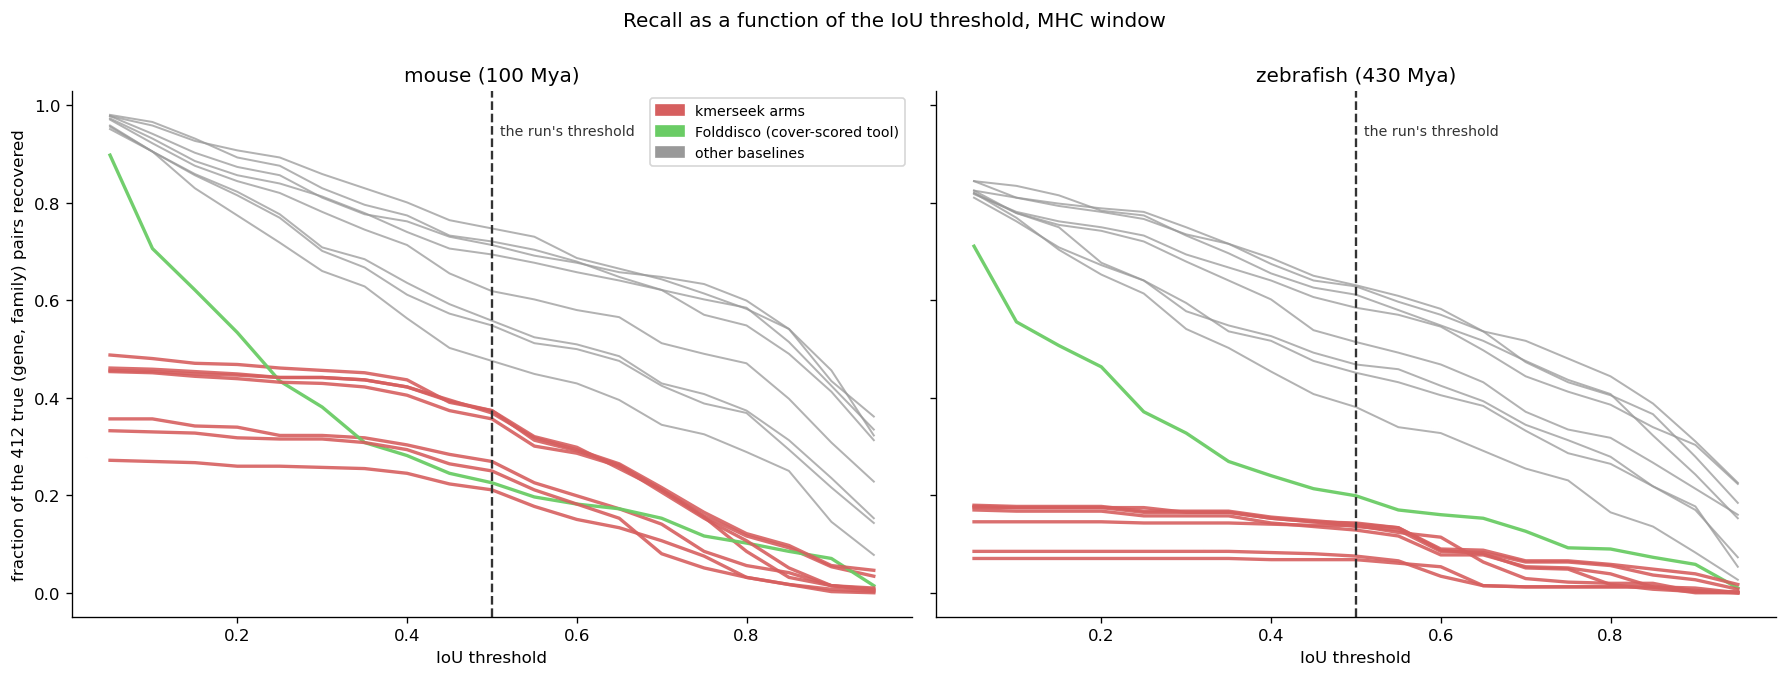

In [4]:
WT = mu.window_truth().select("query_acc", "pfam_id").unique()
print(f"denominator: {WT.height} distinct (gene, family) truth pairs on "
      f"{WT['query_acc'].n_unique()} MHC-window genes")

THS = [round(float(x), 2) for x in np.arange(0.05, 1.0, 0.05)]


def sweep(species):
    best = (mu.focus_calls()
              .filter(pl.col("query_acc").is_in(WIN_ACC) & (pl.col("species") == species))
              .group_by("tool", "variant", "query_acc", "pfam_id")
              .agg(best_iou=pl.col("iou").max())
              .collect())
    g = (WT.join(ARMS, how="cross")
           .join(best, on=["tool", "variant", "query_acc", "pfam_id"], how="left")
           .with_columns(best_iou=pl.col("best_iou").fill_null(0.0),
                         arm=mu.arm_label(pl.col("tool"), pl.col("variant"))))
    rows = []
    for (arm,), s in g.group_by(["arm"]):
        v = s["best_iou"].to_numpy()
        rows += [{"arm": arm, "threshold": t, "recall": float((v >= t).mean())} for t in THS]
    return pl.DataFrame(rows)


sw_mouse, sw_zf = sweep("mouse"), sweep("zebrafish")
SHOW = ["phmmer", "HHblits", "MMseqs2 iterative", "Foldseek", "Reseek", "Folddisco",
        "kmerseek hp_pbotc_1st_ed2_k19", "kmerseek hp_thomas_dill2_k26",
        "kmerseek protein20_k10"]
print("\nmouse, recall against IoU threshold:")
with pl.Config(tbl_rows=25, tbl_width_chars=210, fmt_str_lengths=30):
    print(sw_mouse.filter(pl.col("arm").is_in(SHOW))
                  .with_columns(recall=pl.col("recall").round(3))
                  .pivot(on="arm", index="threshold", values="recall"))

# Where, if anywhere, does a kmerseek curve cross a baseline curve?
KREF = "kmerseek hp_pbotc_1st_ed2_k19"
cross_rows = []
for label, sw in [("mouse", sw_mouse), ("zebrafish", sw_zf)]:
    k = sw.filter(pl.col("arm") == KREF).sort("threshold")
    for arm in sw["arm"].unique().to_list():
        if arm.startswith("kmerseek"):
            continue
        b = sw.filter(pl.col("arm") == arm).sort("threshold")
        diff = k["recall"].to_numpy() - b["recall"].to_numpy()
        sign = np.sign(diff)
        idx = np.where(np.diff(sign) > 0)[0]
        if len(idx):
            i = int(idx[0])
            cross_rows.append({"species": label, "baseline": arm,
                               "crosses_between": f"{THS[i]}–{THS[i + 1]}",
                               "kmerseek_at_0.5": round(float(k["recall"][9]), 3),
                               "baseline_at_0.5": round(float(b["recall"][9]), 3),
                               "kmerseek_at_0.95": round(float(k["recall"][-1]), 3),
                               "baseline_at_0.95": round(float(b["recall"][-1]), 3)})
CROSS = pl.DataFrame(cross_rows) if cross_rows else pl.DataFrame(
    {"species": [], "baseline": []})
print(f"\nBaselines whose curve {KREF} crosses from below:")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=30):
    print(CROSS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.6), sharey=True)
for ax, (label, sw) in zip(axes, [("mouse (100 Mya)", sw_mouse),
                                  ("zebrafish (430 Mya)", sw_zf)]):
    for arm in sw["arm"].unique().to_list():
        s = sw.filter(pl.col("arm") == arm).sort("threshold")
        if arm.startswith("kmerseek"):
            style = dict(color="#D65F5F", lw=2.0, alpha=0.9)
        elif arm == "Folddisco":
            style = dict(color="#6ACC65", lw=2.0, alpha=0.95)
        else:
            style = dict(color="#999999", lw=1.2, alpha=0.75)
        ax.plot(s["threshold"], s["recall"], **style)
    ax.axvline(0.5, color="#333333", lw=1.4, ls="--")
    ax.text(0.51, 0.94, "the run's threshold", fontsize=8.5, color="#333333")
    ax.set_xlabel("IoU threshold")
    ax.set_title(label)
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
axes[0].set_ylabel(f"fraction of the {WT.height} true (gene, family) pairs recovered")
axes[0].legend(handles=[mpatches.Patch(color="#D65F5F", label="kmerseek arms"),
                        mpatches.Patch(color="#6ACC65", label="Folddisco (cover-scored tool)"),
                        mpatches.Patch(color="#999999", label="other baselines")],
               fontsize=8.5, loc="upper right")
fig.suptitle("Recall as a function of the IoU threshold, MHC window", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "224_iou_threshold_sweep.png", dpi=200)

There is one crossover and it is with Folddisco.

In mouse, `hp_pbotc_1st_ed2_k19` is below Folddisco at loose thresholds — 0.46 against 0.90 at
IoU 0.05 — crosses it between 0.20 and 0.25, and stays above it all the way out: 0.37 against
0.23 at the run's 0.5, and 0.046 against 0.015 at 0.95. In zebrafish it crosses the same curve
much later, between 0.90 and 0.95, ending at 0.017 against 0.010. Against the other eight
baselines it is below at every threshold in both species.

The crossover is real and its interpretation is narrow. Folddisco's curve falls steeply because
Folddisco is a motif matcher whose regions are not meant to delimit anything, and the pipeline
scores it on cover rather than IoU for exactly that reason (notebook
[223](./223_mhc_platform_vs_ig_domain.ipynb) §7). Reading the crossover as "kmerseek beats
Folddisco" would apply to Folddisco the metric its own pipeline arm does not use. What it does
show is that kmerseek's recall is the flattest curve among the arms whose calls are short: it
loses less than any other arm between IoU 0.05 and IoU 0.95, because most of the calls it makes
are already tight.

Every other number in these notebooks stays read at 0.5.

## 4. The alphabet ordering survives a metric that dislikes the tool

Sections 2 and 3 are competitive comparisons and kmerseek loses them. That makes the next
question worth asking on purpose: within kmerseek, does the HP encoding still beat the
alternatives when scored by a rule that is bad for kmerseek overall?

This is an internal control, not a competitive claim. Nothing here is measured against a
baseline. If the HP advantage were an artifact of choosing a metric that flatters it, a metric
that does not flatter it should erase the ordering.

MHC-window genes delimited (of 221), kmerseek arms only:
shape: (7, 10)
┌─────────────────────────────┬───────┬─────────┬───────────┬───┬──────┬───────┬─────────────┬───────┐
│ variant                     ┆ mouse ┆ chicken ┆ zebrafish ┆ … ┆ worm ┆ yeast ┆ arabidopsis ┆ ecoli │
│ ---                         ┆ ---   ┆ ---     ┆ ---       ┆   ┆ ---  ┆ ---   ┆ ---         ┆ ---   │
│ str                         ┆ u32   ┆ u32     ┆ u32       ┆   ┆ u32  ┆ u32   ┆ u32         ┆ u32   │
╞═════════════════════════════╪═══════╪═════════╪═══════════╪═══╪══════╪═══════╪═════════════╪═══════╡
│ hp_thomas_dill2_k26_lcTrue  ┆ 115   ┆ 40      ┆ 54        ┆ … ┆ 33   ┆ 5     ┆ 10          ┆ 0     │
│ hp_pbotc_1st_ed2_k24_lcTrue ┆ 112   ┆ 34      ┆ 48        ┆ … ┆ 38   ┆ 7     ┆ 10          ┆ 0     │
│ hp_pbotc_1st_ed2_k21_lcTrue ┆ 112   ┆ 43      ┆ 50        ┆ … ┆ 43   ┆ 14    ┆ 10          ┆ 0     │
│ hp_pbotc_1st_ed2_k19_lcTrue ┆ 110   ┆ 45      ┆ 52        ┆ … ┆ 45   ┆ 16    ┆ 10          ┆ 0     │
│

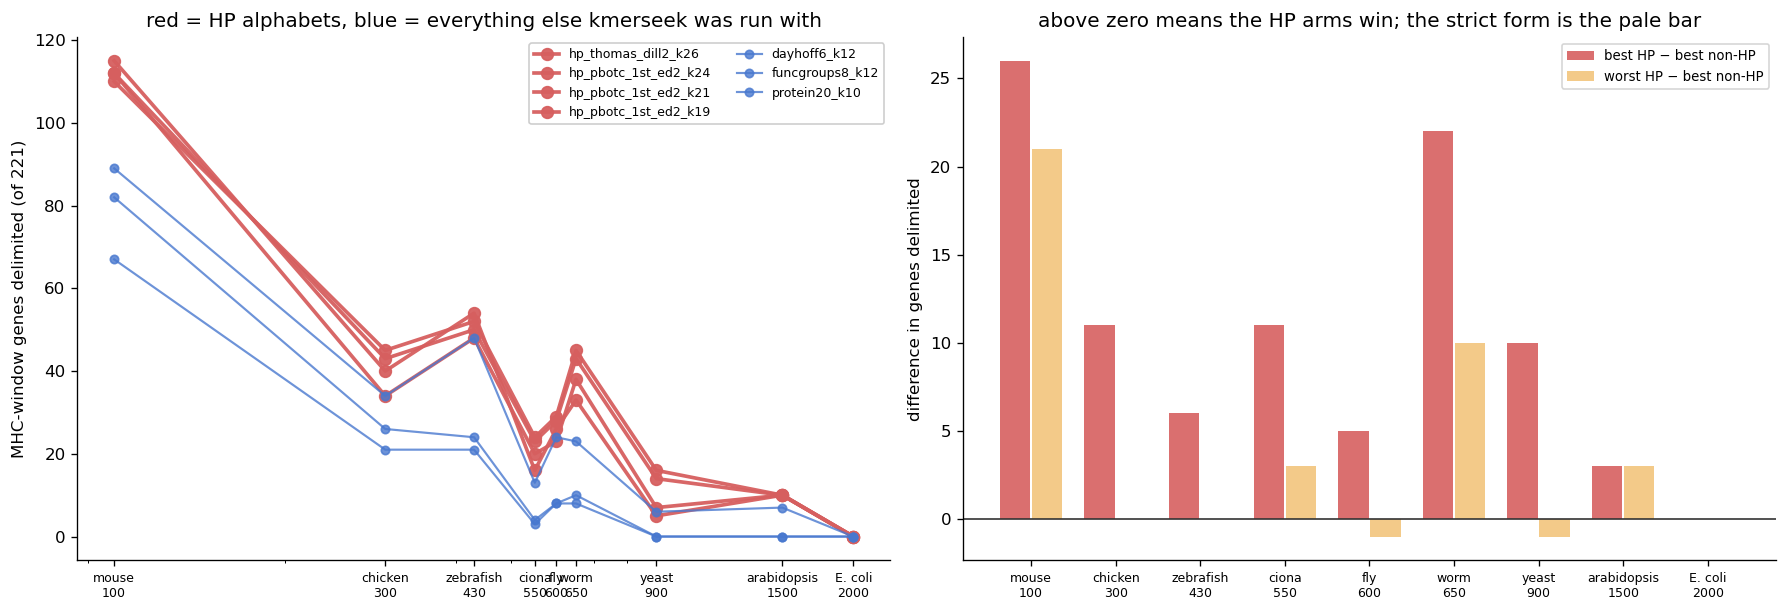

In [5]:
km = (states.filter(pl.col("tool") == "kmerseek")
            .group_by("species", "variant")
            .agg(delimited=(pl.col("state") == "delimited").sum(),
                 called=(pl.col("state") != "not called").sum()))
KM_LABEL = {v: v.replace("_lcTrue", "") for v in KM_ARMS}
wide = (km.pivot(on="species", index="variant", values="delimited")
          .select(["variant"] + SP)
          .sort("mouse", descending=True))
print(f"MHC-window genes delimited (of {window.height}), kmerseek arms only:")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=42):
    print(wide)
hp_min = wide.filter(pl.col("variant").is_in(HP_ARMS))["mouse"].min()
p20 = wide.filter(pl.col("variant") == "protein20_k10_lcTrue")["mouse"][0]
print(f"\nmouse: worst HP arm {hp_min}, protein20_k10 {p20}, ratio {hp_min / p20:.2f}x")
wins = []
for sp in SP:
    col = wide[sp].to_list()
    variants = wide["variant"].to_list()
    hp = [c for v, c in zip(variants, col) if v in HP_ARMS]
    other = [c for v, c in zip(variants, col) if v not in HP_ARMS]
    wins.append({"species": sp, "best_HP": max(hp), "worst_HP": min(hp),
                 "best_non_HP": max(other),
                 "best_HP_wins": max(hp) > max(other),
                 "every_HP_wins": min(hp) > max(other)})
W = pl.DataFrame(wins)
print("\nTwo readings of the ordering. `best_HP_wins` compares the best HP arm against the")
print("best non-HP arm; `every_HP_wins` is the strict form, worst HP against best non-HP.")
with pl.Config(tbl_rows=20, tbl_width_chars=170):
    print(W)
print(f"\nbest HP beats best non-HP in {W['best_HP_wins'].sum()} of {W.height} species; "
      f"the strict form holds in {W['every_HP_wins'].sum()}.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
x = [mu.SPECIES_MYA[s] for s in SP]
for v in wide["variant"].to_list():
    ys = wide.filter(pl.col("variant") == v).select(SP).row(0)
    hp = v in HP_ARMS
    axes[0].plot(x, ys, "o-", lw=2.2 if hp else 1.3, ms=7 if hp else 5,
                 color="#D65F5F" if hp else "#4878CF", alpha=0.95 if hp else 0.8,
                 label=KM_LABEL.get(v, v))
axes[0].set_xscale("log")
axes[0].set_xticks(x)
axes[0].set_xticklabels([mu.SPECIES_LABELS[s] for s in SP], fontsize=7.5)
axes[0].set_ylabel(f"MHC-window genes delimited (of {window.height})")
axes[0].set_title("red = HP alphabets, blue = everything else kmerseek was run with")
axes[0].legend(fontsize=7.5, ncol=2, framealpha=0.95)
gap = W.with_columns(best_gap=pl.col("best_HP") - pl.col("best_non_HP"),
                     strict_gap=pl.col("worst_HP") - pl.col("best_non_HP"))
gx = np.arange(gap.height)
axes[1].bar(gx - 0.19, gap["best_gap"], 0.36, color="#D65F5F", alpha=0.9,
            label="best HP − best non-HP")
axes[1].bar(gx + 0.19, gap["strict_gap"], 0.36, color="#F2C57C", alpha=0.9,
            label="worst HP − best non-HP")
axes[1].axhline(0, color="#333333", lw=1.0)
axes[1].set_xticks(gx)
axes[1].set_xticklabels([mu.SPECIES_LABELS[s] for s in gap["species"]], fontsize=7.5)
axes[1].set_ylabel("difference in genes delimited")
axes[1].set_title("above zero means the HP arms win; the strict form is the pale bar")
axes[1].legend(fontsize=8)
for ax in axes:
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "224_hp_ordering_internal_control.png", dpi=200)

The ordering holds, on a metric that costs kmerseek the comparison against every baseline.

In mouse the four HP arms delimit 115, 112, 112 and 110 of the 221 window genes against
`protein20_k10`'s 67 — the weakest HP arm is 1.64 times the plain amino-acid encoding.
`dayhoff6_k12` sits between at 89 and `funcgroups8_k12` at 82, so the ordering is
HP > dayhoff6 > funcgroups8 > protein20, which is what compressing the alphabet toward
hydrophobic/polar predicts.

The best HP arm beats the best non-HP arm in eight of the nine species: 115 to 89 in mouse, 45
to 34 in chicken, 54 to 48 in zebrafish, 24 to 13 in ciona, 29 to 24 in fly, 45 to 23 in worm,
16 to 6 in yeast and 10 to 7 in arabidopsis. In E. coli every kmerseek arm is at 0 and the
question does not arise.

The strict form is weaker and is reported as such. Asking whether *every* HP arm beats every
non-HP arm holds in only four species — mouse, ciona, worm and arabidopsis. In chicken and
zebrafish the worst HP arm ties `dayhoff6_k12`, and in fly and yeast a non-HP arm beats the
worst HP arm outright. The HP alphabets are not uniformly better than dayhoff6; the best of them
is, consistently.

This is worth more than it looks. Section 2's metric is the one on which kmerseek delimits 110
window genes to phmmer's 204. The HP advantage is measured on that same unflattering rule and
survives it, so it is not an artifact of picking a metric that suits the method.

It is still an internal comparison. It says the HP encoding is the right choice among kmerseek's
alphabets on the MHC region. It says nothing about kmerseek against anything else, and §2 and
§3 already answered that question the other way.

## 5. What kmerseek is calling past the annotation floor

From ciona outward there is no MHC molecule in the answer key, and yet the kmerseek arms keep
making calls on MHC-window genes. Section 1 said the benchmark cannot score those. This section
counts them anyway, as a census.

The gray zone is the pipeline's own category for a call whose residues lie mostly outside any
Pfam annotation on that query protein. The reasoning in `evaluate_domain_calls.py` is that Pfam
is silent outside its annotations rather than negative, so counting such a call as a false
positive would assert that the annotation looked there and found nothing. Those calls are
excluded from the precision denominator and are neither true nor false positives.

**Nothing below is a claim that these calls are right.** They are unscored by construction.
This is a table of what a hypothesis-generating follow-up would have to look at, with every
count carrying its n.

Gray-zone exclusion, kmerseek HP arms, MHC-window genes:
shape: (12, 7)
┌─────────┬─────────────────────────────┬─────────┬────────┬──────┬─────────────┬───────────┐
│ species ┆ variant                     ┆ n_calls ┆ n_gray ┆ n_tp ┆ n_scoreable ┆ frac_gray │
│ ---     ┆ ---                         ┆ ---     ┆ ---    ┆ ---  ┆ ---         ┆ ---       │
│ str     ┆ str                         ┆ u32     ┆ u32    ┆ u32  ┆ u32         ┆ f64       │
╞═════════╪═════════════════════════════╪═════════╪════════╪══════╪═════════════╪═══════════╡
│ ciona   ┆ hp_pbotc_1st_ed2_k19_lcTrue ┆ 1874    ┆ 690    ┆ 84   ┆ 1184        ┆ 0.368     │
│ ciona   ┆ hp_pbotc_1st_ed2_k21_lcTrue ┆ 893     ┆ 309    ┆ 71   ┆ 584         ┆ 0.346     │
│ ciona   ┆ hp_pbotc_1st_ed2_k24_lcTrue ┆ 254     ┆ 65     ┆ 43   ┆ 189         ┆ 0.256     │
│ ciona   ┆ hp_thomas_dill2_k26_lcTrue  ┆ 257     ┆ 135    ┆ 26   ┆ 122         ┆ 0.525     │
│ fly     ┆ hp_pbotc_1st_ed2_k19_lcTrue ┆ 1727    ┆ 577    ┆ 80   ┆ 1150        ┆ 

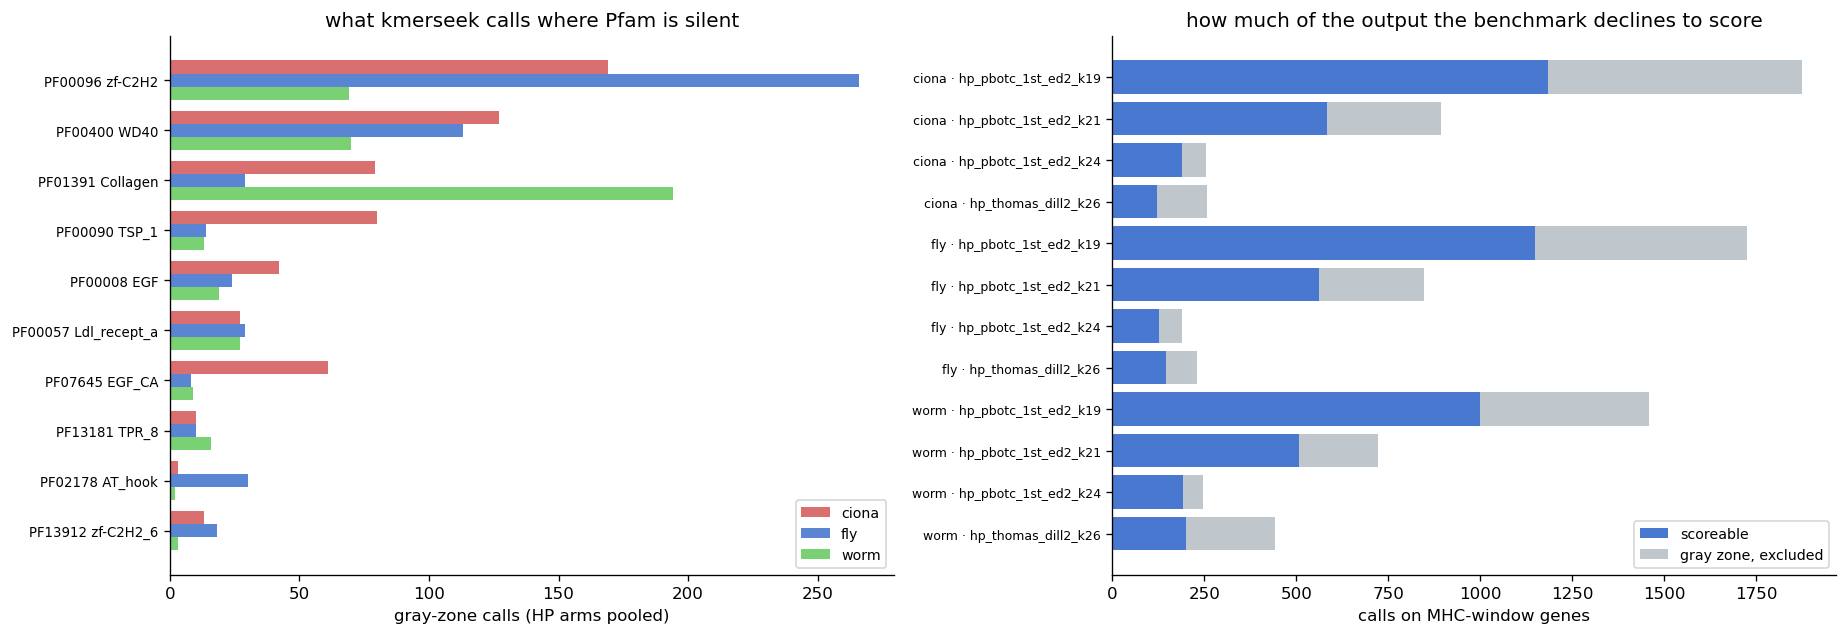

In [6]:
CENSUS_SP = ["ciona", "fly", "worm"]
calls = (mu.focus_calls()
           .filter(pl.col("species").is_in(CENSUS_SP) & (pl.col("tool") == "kmerseek")
                   & pl.col("variant").is_in(HP_ARMS) & pl.col("query_acc").is_in(WIN_ACC))
           .select("species", "variant", "query_acc", "pfam_id", "is_gray", "is_tp", "score")
           .collect())
totals = (calls.group_by("species", "variant")
               .agg(n_calls=pl.len(), n_gray=pl.col("is_gray").sum(),
                    n_tp=pl.col("is_tp").sum())
               .with_columns(n_scoreable=pl.col("n_calls") - pl.col("n_gray"),
                             frac_gray=(pl.col("n_gray") / pl.col("n_calls")).round(3))
               .sort("species", "variant"))
print("Gray-zone exclusion, kmerseek HP arms, MHC-window genes:")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=42):
    print(totals)
print(f"\nTotal calls {calls.height:_}; gray-zone excluded {calls['is_gray'].sum():_} "
      f"({calls['is_gray'].mean():.1%}); scoreable {calls.height - calls['is_gray'].sum():_}.")

names = mu.load_pfam_names()
gray = calls.filter(pl.col("is_gray"))
per_fam = (gray.group_by("species", "pfam_id")
               .agg(n_calls=pl.len(), n_genes=pl.col("query_acc").n_unique(),
                    n_arms=pl.col("variant").n_unique()))
recur = (per_fam.group_by("pfam_id")
                .agg(n_species=pl.col("species").n_unique(),
                     n_calls_total=pl.col("n_calls").sum(),
                     n_genes_total=pl.col("n_genes").sum())
                .join(names, on="pfam_id", how="left")
                .sort(["n_species", "n_calls_total"], descending=True))
print(f"\nDistinct Pfam families among the gray-zone calls: {per_fam['pfam_id'].n_unique()}")
print(f"Families appearing in all three species: "
      f"{recur.filter(pl.col('n_species') == 3).height}")
print("\nTop families by pooled gray-zone call count (n_species = how many of ciona/fly/worm):")
with pl.Config(tbl_rows=20, tbl_width_chars=200, fmt_str_lengths=50):
    print(recur.head(15).select("pfam_id", "pfam_name", "n_species", "n_calls_total",
                                "n_genes_total", "pfam_desc"))
print("\nNo true/false-positive claim attaches to any row above. These calls sit outside")
print("Pfam's annotated territory on the query, so the benchmark has no opinion on them.")

TOP = recur.head(10)["pfam_id"].to_list()
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.4))
y = np.arange(len(TOP))
w = 0.26
for i, sp in enumerate(CENSUS_SP):
    vals = [per_fam.filter((pl.col("species") == sp) & (pl.col("pfam_id") == f))["n_calls"].sum()
            for f in TOP]
    axes[0].barh(y + (i - 1) * w, vals, w, label=sp,
                 color=["#D65F5F", "#4878CF", "#6ACC65"][i], alpha=0.9)
lab = dict(names.select("pfam_id", "pfam_name").iter_rows())
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{f} {lab.get(f, '')}" for f in TOP], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("gray-zone calls (HP arms pooled)")
axes[0].set_title("what kmerseek calls where Pfam is silent")
axes[0].legend(fontsize=8.5)
t = totals.sort("species", "variant")
y2 = np.arange(t.height)
axes[1].barh(y2, t["n_scoreable"], color="#4878CF", label="scoreable")
axes[1].barh(y2, t["n_gray"], left=t["n_scoreable"], color="#BFC6CC",
             label="gray zone, excluded")
axes[1].set_yticks(y2)
axes[1].set_yticklabels([f"{s} · {v.replace('_lcTrue', '')}"
                         for s, v in zip(t["species"], t["variant"])], fontsize=7.5)
axes[1].invert_yaxis()
axes[1].set_xlabel("calls on MHC-window genes")
axes[1].set_title("how much of the output the benchmark declines to score")
axes[1].legend(fontsize=8.5)
for ax in axes:
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "224_gray_zone_census.png", dpi=200)

The recurring families are short repeat modules, which is the least interesting explanation and
the one the counts support.

Across ciona, fly and worm the four HP arms make 9,142 calls on MHC-window genes, of which
3,182 (34.8%) fall in the gray zone and are excluded from scoring; 5,960 remain scoreable. The
gray-zone calls spread over 327 distinct Pfam families, and 41 of those appear in all three
species. The families carrying the most are zf-C2H2 (PF00096, 504 calls over 170 gene-species
cells), WD40 (PF00400, 310), Collagen (PF01391, 302), TSP_1 (PF00090, 107), EGF (PF00008, 85)
and Ldl_recept_a (PF00057, 83). The gray fraction ranges from 22.0% (`hp_pbotc_1st_ed2_k24` in
worm) to 55.1% (`hp_thomas_dill2_k26` in worm) across the twelve arm-species cells.

Every one of those is a short tandem module with strong compositional bias, which is what a
k-mer method matches on when there is no real homology left, and the recurrence across three
unrelated invertebrates is what a compositional artifact looks like rather than what a
conserved cryptic domain looks like. No MHC-related family appears anywhere in the list.

That is not proof these calls are wrong; the gray zone exists precisely because the benchmark
cannot say. It is a reason not to present them as an unrecognised signal without an
HP-composition-matched null to compare them against, which this run does not have.

## Summary

MHC molecules delimited, of 24, by species:
shape: (2, 10)
┌─────────────┬───────┬─────────┬───────────┬───┬──────┬───────┬─────────────┬───────┐
│ group       ┆ mouse ┆ chicken ┆ zebrafish ┆ … ┆ worm ┆ yeast ┆ arabidopsis ┆ ecoli │
│ ---         ┆ ---   ┆ ---     ┆ ---       ┆   ┆ ---  ┆ ---   ┆ ---         ┆ ---   │
│ str         ┆ i64   ┆ i64     ┆ i64       ┆   ┆ i64  ┆ i64   ┆ i64         ┆ i64   │
╞═════════════╪═══════╪═════════╪═══════════╪═══╪══════╪═══════╪═════════════╪═══════╡
│ baselines   ┆ 24    ┆ 24      ┆ 24        ┆ … ┆ 2    ┆ 2     ┆ 2           ┆ 2     │
│ kmerseek HP ┆ 5     ┆ 1       ┆ 0         ┆ … ┆ 0    ┆ 0     ┆ 0           ┆ 0     │
└─────────────┴───────┴─────────┴───────────┴───┴──────┴───────┴─────────────┴───────┘

mouse window genes, phmmer: delimited 204, kmerseek hp k19: 110 of 221
best-HP-beats-best-non-HP in 8 of 9 species; strict form in 4
gray-zone calls censused: 3_182 of 9_142


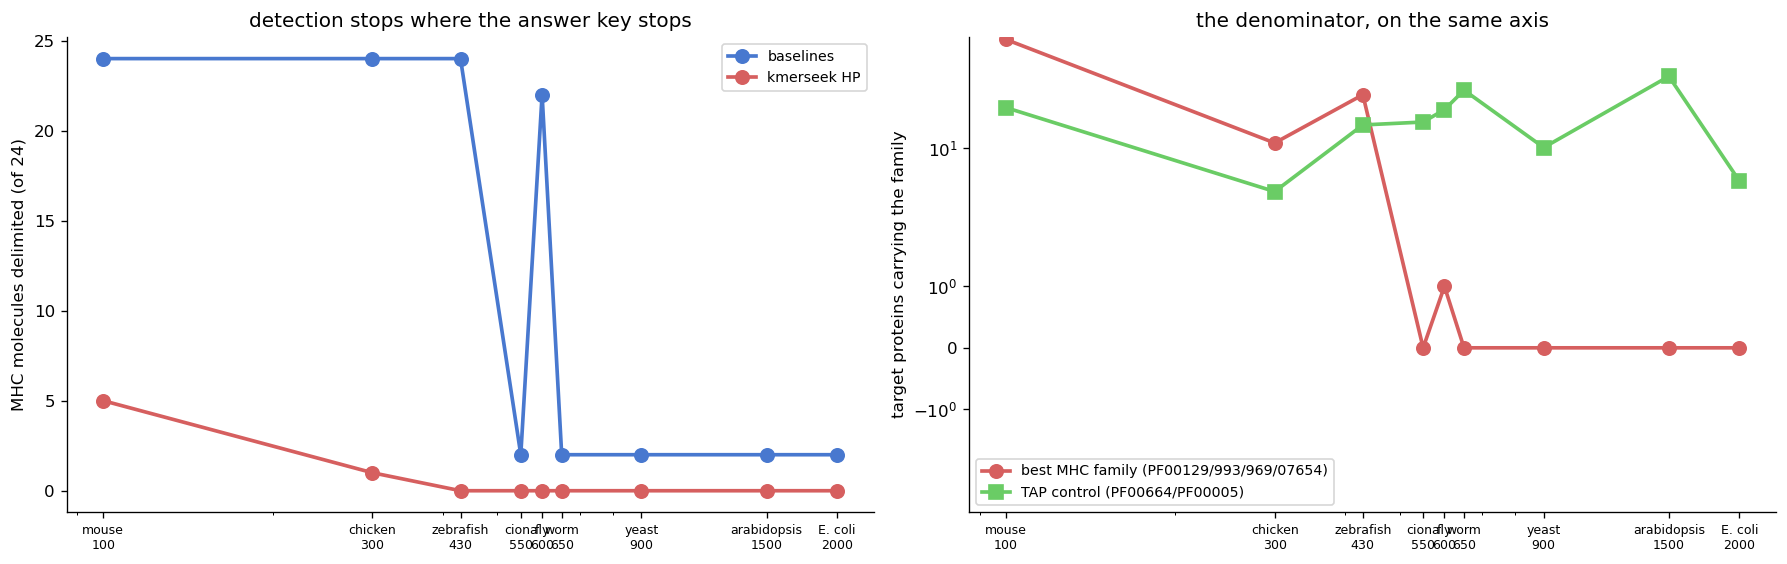

In [7]:
rows = []
for grp in ["baselines", "kmerseek HP"]:
    for sp in SP:
        s = gene_state.filter((pl.col("group") == grp) & (pl.col("species") == sp))
        rows.append({"group": grp, "species": sp,
                     "delimited": int((s["state"] == "delimited").sum()),
                     "of": s.height})
FINAL = pl.DataFrame(rows)
print("MHC molecules delimited, of 24, by species:")
with pl.Config(tbl_rows=25, tbl_width_chars=160):
    print(FINAL.pivot(on="species", index="group", values="delimited").select(["group"] + SP))
m = tab.filter(pl.col("species") == "mouse")
print(f"\nmouse window genes, phmmer: delimited {m.filter(pl.col('tool') == 'hmmer3_phmmer')['delimited'][0]}"
      f", kmerseek hp k19: {m.filter(pl.col('arm') == 'kmerseek hp_pbotc_1st_ed2_k19')['delimited'][0]}"
      f" of {window.height}")
print(f"best-HP-beats-best-non-HP in {W['best_HP_wins'].sum()} of {W.height} species; "
      f"strict form in {W['every_HP_wins'].sum()}")
print(f"gray-zone calls censused: {gray.height:_} of {calls.height:_}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
x = [mu.SPECIES_MYA[s] for s in SP]
for grp, colour in [("baselines", "#4878CF"), ("kmerseek HP", "#D65F5F")]:
    ys = [FINAL.filter((pl.col("group") == grp) & (pl.col("species") == s))["delimited"][0]
          for s in SP]
    axes[0].plot(x, ys, "o-", lw=2.2, ms=8, color=colour, label=grp)
tapn = [reach_fam.filter((pl.col("species") == s)
                         & pl.col("pfam_id").is_in(["PF00664", "PF00005"]))["n_target_proteins"].min()
        for s in SP]
mhcn = [reach_fam.filter((pl.col("species") == s)
                         & pl.col("pfam_id").is_in(["PF00129", "PF00993", "PF00969", "PF07654"]))
                 ["n_target_proteins"].max() for s in SP]
axes[0].set_xscale("log")
axes[0].set_xticks(x)
axes[0].set_xticklabels([mu.SPECIES_LABELS[s] for s in SP], fontsize=7.5)
axes[0].set_ylabel("MHC molecules delimited (of 24)")
axes[0].set_title("detection stops where the answer key stops")
axes[0].legend(fontsize=8.5)
axes[1].plot(x, mhcn, "o-", lw=2.2, ms=8, color="#D65F5F",
             label="best MHC family (PF00129/993/969/07654)")
axes[1].plot(x, tapn, "s-", lw=2.2, ms=8, color="#6ACC65",
             label="TAP control (PF00664/PF00005)")
axes[1].set_xscale("log")
axes[1].set_yscale("symlog")
axes[1].set_xticks(x)
axes[1].set_xticklabels([mu.SPECIES_LABELS[s] for s in SP], fontsize=7.5)
axes[1].set_ylabel("target proteins carrying the family")
axes[1].set_title("the denominator, on the same axis")
axes[1].legend(fontsize=8.5)
for ax in axes:
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "224_summary.png", dpi=200)

**Detection tracks the annotation, not the divergence.** The nine baselines delimit all 24
curated genes in mouse, chicken and zebrafish, and exactly 2 — TAP1 and TAP2 — in ciona, worm,
yeast, arabidopsis and E. coli. Fly breaks the monotonic reading: at 600 Mya, further out than
ciona, the baselines delimit 22 of 24, entirely because one fly protein (Q9W257, 229 residues,
C1-set as its only Pfam family) is the single PF07654 entry in that proteome. One annotated
protein moves the score from 0 to 20 MHC molecules. TAP1 and TAP2, whose ABC families are
annotated in all nine proteomes, are delimited in all nine including E. coli. So the benchmark
cannot separate "MHC molecules stopped being findable" from "Pfam stopped annotating them", and
any MHC recall number past zebrafish measures Pfam's coverage while reading like a statement
about homology.

**"kmerseek finds the territory and misses the fenceline" is not what this run shows.** In
mouse, kmerseek k19 calls 220 of 221 window genes against phmmer's 219 and delimits 110 against
phmmer's 204. But conditioned on making a call carrying a family the gene actually has, kmerseek
delimits 110 of 117 (94.0%) and phmmer 204 of 218 (93.6%). kmerseek's loss is in family assignment,
not boundary placement, and notebook [223](./223_mhc_platform_vs_ig_domain.ipynb) §9 shows its
boundaries are the tightest in the run. The Pareto trade is real; the axis it loses is
sensitivity, which is the axis the headline number reports.

**One crossover on the IoU sweep, and it is with the tool that is not scored on IoU.** kmerseek
hp k19 crosses Folddisco between IoU 0.20 and 0.25 in mouse and stays above it to 0.95. Against
the other eight baselines it is below at every threshold in both mouse and zebrafish. Folddisco
is scored on cover in its own pipeline arm, so the crossover is a statement about how flat
kmerseek's curve is, not a win. Nothing here relaxes the 0.5 threshold used everywhere else.

**The HP alphabet ordering survives the unflattering metric.** On the same rule that gives
kmerseek 110 window genes to phmmer's 204, the four HP arms delimit 115/112/112/110 in mouse
against protein20_k10's 67, with dayhoff6 at 89 and funcgroups8 at 82. The best HP arm beats the
best non-HP kmerseek arm in eight of the nine species, the exception being E. coli where every
arm is at 0. The strict form — every HP arm beating every non-HP arm — holds in only four
species; in fly and yeast a non-HP arm beats the weakest HP arm. So the claim is that the best
HP encoding is consistently the best kmerseek alphabet here, not that all HP arms dominate. It
is an internal control and says nothing about kmerseek against other tools.

**Past the annotation floor there is a census and no claim.** In ciona, fly and worm the HP arms
make 9,142 calls on MHC-window genes and 3,182 of them (34.8%) land in the gray zone, spread
over 327 families of which 41 recur in all three species. The most frequent are zf-C2H2 (504),
WD40 (310), Collagen (302), TSP_1 (107), EGF (85) and Ldl_recept_a (83) — short tandem modules
with strong compositional bias, which is what a k-mer method finds when there is no homology
left. No MHC-related family appears. These calls are unscored by construction and are reported
as something to look at, not as a finding.